# 🏥 Pneumonia Detection System
## Multi-Agent AI Pipeline for Medical Imaging Analysis

### 🎯 Project Overview
This notebook implements an end-to-end pneumonia detection system that combines:
- **Computer Vision** (Roboflow RF-DETR) for X-ray analysis
- **Retrieval-Augmented Generation (RAG)** for medical knowledge
- **Vision-Language Model** (LLaVA) for clinical interpretation
- **LangGraph** for multi-agent orchestration
- **Gradio** for professional web interface

### 🏗️ System Architecture
```
Chest X-Ray Input
    ↓
┌─────────────────────────────────────────────────┐
│  Agent 1: Vision Detection (Roboflow)          │
│  - Detects pneumonia patterns                   │
│  - Extracts regions of interest (ROI)          │
│  - Generates confidence scores                  │
└─────────────────────────────────────────────────┘
    ↓
┌─────────────────────────────────────────────────┐
│  Agent 2: Medical Knowledge RAG                 │
│  - Retrieves relevant medical context          │
│  - Uses FAISS vector database                  │
│  - Provides evidence-based guidelines          │
└─────────────────────────────────────────────────┘
    ↓
┌─────────────────────────────────────────────────┐
│  Agent 3: LLM Interpretation (LLaVA)           │
│  - Analyzes visual + structured findings       │
│  - Generates clinical explanation              │
│  - Provides confidence-based assessment        │
└─────────────────────────────────────────────────┘
    ↓
┌─────────────────────────────────────────────────┐
│  Agent 4: Medical Disclaimer                    │
│  - Adds ethical compliance                      │
│  - Provides legal disclaimers                   │
│  - Formats final output                         │
└─────────────────────────────────────────────────┘
    ↓
Professional Report + PDF Export
```

### 📊 Key Technologies
- **LangGraph**: State machine orchestration
- **LLaVA-1.5-7B**: Vision-language understanding
- **FAISS**: Vector similarity search
- **Gradio**: Interactive web UI
- **ReportLab**: PDF generation

### 🎓 Learning Objectives
This project demonstrates:
1. Multi-agent system design
2. Medical AI ethics and compliance
3. RAG implementation for domain knowledge
4. Production-ready ML deployment
5. Human-in-the-loop AI systems

---

In [1]:
!pip install inference-sdk
!pip install pydantic
!pip install pillow
!pip install requests


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.7/65.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.4/212.4 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.13.0.90
    Uninstalling opencv-python-4.13.0.90:
      Successfully uninstalled opencv-python-4.13.0.90
  Attempting uninstall: aiohttp
    Found existing installation: aiohttp 3.13.3
    Uninstalling aiohttp-3.13.3:
      Successfully uninstalled aiohttp-3.13.3


In [2]:
from inference_sdk import InferenceHTTPClient
import json

class VisionAgent:
    def __init__(self, api_key):
        self.client = InferenceHTTPClient(
            api_url="https://serverless.roboflow.com",
            api_key=api_key
        )

    def infer(self, image_path):
        result = self.client.run_workflow(
            workspace_name="kowshik-products-vndnc",
            workflow_id="custom-workflow",
            images={"image": image_path},
            use_cache=True
        )
        return result


In [3]:
vision_agent = VisionAgent(api_key="SuL5NoGurRtFwpcuGRug")

result = vision_agent.infer("/content/drive/MyDrive/AI School Projects/Pneumonia LLM/person819_bacteria_2730.jpeg")
print(json.dumps(result, indent=2))


[
  {
    "predictions": {
      "image": {
        "width": 864,
        "height": 528
      },
      "predictions": [
        {
          "width": 134.0,
          "height": 190.0,
          "x": 324.0,
          "y": 228.0,
          "confidence": 0.675862193107605,
          "class_id": 1,
          "class": "pneumonia positive",
          "detection_id": "e8b77177-ab31-4830-b639-b51da0923963",
          "parent_id": "image"
        }
      ]
    }
  }
]


In [4]:
def normalize_predictions(result):
    preds = result[0]["predictions"]["predictions"]

    structured = {
        "image_quality": "acceptable",
        "detections": []
    }

    for p in preds:
        structured["detections"].append({
            "label": p["class"],
            "confidence": round(p["confidence"], 3),
            "bbox": {
                "x": p["x"],
                "y": p["y"],
                "width": p["width"],
                "height": p["height"]
            }
        })

    return structured


In [5]:
structured_output = normalize_predictions(result)
structured_output


{'image_quality': 'acceptable',
 'detections': [{'label': 'pneumonia positive',
   'confidence': 0.676,
   'bbox': {'x': 324.0, 'y': 228.0, 'width': 134.0, 'height': 190.0}}]}

In [6]:
def summarize_case(structured):
    labels = [d["label"] for d in structured["detections"]]
    confidences = [d["confidence"] for d in structured["detections"]]

    if all("negative" in l for l in labels):
        overall = "No radiographic evidence of pneumonia detected"
    else:
        overall = "Findings suspicious for pneumonia"

    structured["summary"] = {
        "overall_assessment": overall,
        "mean_confidence": round(sum(confidences) / len(confidences), 3),
        "mean_confidence_percent": round((round(sum(confidences) / len(confidences), 3))* 100, 1)
    }

    return structured


In [7]:
structured_output = summarize_case(structured_output)
structured_output


{'image_quality': 'acceptable',
 'detections': [{'label': 'pneumonia positive',
   'confidence': 0.676,
   'bbox': {'x': 324.0, 'y': 228.0, 'width': 134.0, 'height': 190.0}}],
 'summary': {'overall_assessment': 'Findings suspicious for pneumonia',
  'mean_confidence': 0.676,
  'mean_confidence_percent': 67.6}}

In [8]:
import cv2

def draw_bounding_boxes(image_path, structured, save_path="boxed_output.png"):
    img = cv2.imread(image_path)

    for d in structured["detections"]:
        x = int(d["bbox"]["x"])
        y = int(d["bbox"]["y"])
        w = int(d["bbox"]["width"])
        h = int(d["bbox"]["height"])

        x1, y1 = int(x - w/2), int(y - h/2)
        x2, y2 = int(x + w/2), int(y + h/2)

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            img,
            f"{d['label']} ({d['confidence']})",
            (x1, max(y1 - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

    cv2.imwrite(save_path, img)
    return save_path


In [9]:
boxed_image_path = draw_bounding_boxes(
    "/content/drive/MyDrive/AI School Projects/Pneumonia LLM/person819_bacteria_2730.jpeg",
    structured_output
)


In [10]:
def crop_rois(image_path, structured):
    img = cv2.imread(image_path)
    roi_paths = []

    for i, d in enumerate(structured["detections"]):
        x = int(d["bbox"]["x"])
        y = int(d["bbox"]["y"])
        w = int(d["bbox"]["width"])
        h = int(d["bbox"]["height"])

        x1, y1 = int(x - w/2), int(y - h/2)
        x2, y2 = int(x + w/2), int(y + h/2)

        roi = img[y1:y2, x1:x2]
        roi_path = f"/content/roi_{i}.png"
        cv2.imwrite(roi_path, roi)
        roi_paths.append(roi_path)

    return roi_paths


In [11]:
roi_images = crop_rois(
    "/content/drive/MyDrive/AI School Projects/Pneumonia LLM/person819_bacteria_2730.jpeg",
    structured_output
)


In [12]:
llm_payload = {
    "vision_source": "Roboflow RF-DETR (serverless)",
    "structured_findings": structured_output,
    "roi_images": roi_images
}

print(json.dumps(llm_payload, indent=2))


{
  "vision_source": "Roboflow RF-DETR (serverless)",
  "structured_findings": {
    "image_quality": "acceptable",
    "detections": [
      {
        "label": "pneumonia positive",
        "confidence": 0.676,
        "bbox": {
          "x": 324.0,
          "y": 228.0,
          "width": 134.0,
          "height": 190.0
        }
      }
    ],
    "summary": {
      "overall_assessment": "Findings suspicious for pneumonia",
      "mean_confidence": 0.676,
      "mean_confidence_percent": 67.6
    }
  },
  "roi_images": [
    "/content/roi_0.png"
  ]
}


In [13]:
SYSTEM_PROMPT = """
You are a medical imaging assistant.

A computer vision model has already analyzed a chest X-ray.
You MUST rely only on the provided detections and images.

Do NOT introduce new findings.
Use cautious medical language.
State uncertainty when confidence is below 0.7.
"""
USER_PROMPT = f"""
Structured findings:
{json.dumps(structured_output, indent=2)}

Explain whether the findings are consistent with pneumonia or normal lungs.
"""


In [2]:
!pip install transformers accelerate pillow bitsandbytes




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 15.3 MB/s eta 0:00:00


In [14]:
import torch
from transformers import LlavaProcessor, LlavaForConditionalGeneration
from PIL import Image

# ============================================
# STEP 1: Verify GPU is available
# ============================================
print("Checking GPU availability...")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("⚠️ WARNING: No GPU detected!")
    print("Go to: Runtime > Change runtime type > Hardware accelerator > T4 GPU")
    print("Then click 'Save' and rerun this cell")
    raise RuntimeError("GPU required for this model")

# ============================================
# STEP 2: Load model with GPU
# ============================================
model_id = "llava-hf/llava-1.5-7b-hf"

print(f"\nLoading processor from {model_id}...")
processor = LlavaProcessor.from_pretrained(model_id)

print(f"Loading model from {model_id}...")
print("This may take 2-5 minutes on first run (downloading ~14GB)...")

model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,  # Use FP16 for GPU efficiency
    device_map="auto",          # Automatically use GPU
    low_cpu_mem_usage=True      # Optimize memory during loading
)

# ============================================
# STEP 3: Verify model is on GPU
# ============================================
print("\n" + "="*50)
print("MODEL LOADED SUCCESSFULLY!")
print("="*50)
print(f"Model device: {model.device}")
print(f"Model dtype: {model.dtype}")

# Check which device the model layers are on
first_layer_device = next(model.parameters()).device
print(f"First layer on: {first_layer_device}")

if first_layer_device.type == "cuda":
    print("✅ Model successfully loaded on GPU!")
else:
    print("⚠️ WARNING: Model is on CPU, not GPU!")

print("="*50)

Checking GPU availability...
CUDA available: True
GPU Device: Tesla T4
GPU Memory: 14.74 GB

Loading processor from llava-hf/llava-1.5-7b-hf...


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
`torch_dtype` is deprecated! Use `dtype` instead!


Loading model from llava-hf/llava-1.5-7b-hf...
This may take 2-5 minutes on first run (downloading ~14GB)...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]


MODEL LOADED SUCCESSFULLY!
Model device: cuda:0
Model dtype: torch.float16
First layer on: cuda:0
✅ Model successfully loaded on GPU!


---

# 🧠 Part 2: Medical Knowledge Retrieval (RAG)

## Why RAG for Medical AI?

Medical diagnosis requires **evidence-based reasoning**. Our RAG system ensures:
- ✅ Responses grounded in medical literature
- ✅ Reduced hallucination risk
- ✅ Traceable sources for clinical validation
- ✅ Up-to-date medical guidelines

## RAG Architecture
```
User Query
    ↓
┌──────────────────────────────┐
│  Query Construction          │
│  (from detection results)    │
└──────────────────────────────┘
    ↓
┌──────────────────────────────┐
│  Embedding Model             │
│  (all-MiniLM-L6-v2)         │
└──────────────────────────────┘
    ↓
┌──────────────────────────────┐
│  FAISS Vector Search         │
│  (similarity matching)       │
└──────────────────────────────┘
    ↓
┌──────────────────────────────┐
│  Top-K Medical Contexts      │
│  (evidence-based snippets)   │
└──────────────────────────────┘
```

## Knowledge Source
We use curated medical content from **Center Surgent Care's Pneumonia X-Ray Guide**, which provides:
- Radiographic signs of pneumonia
- Differential diagnosis criteria
- Common patterns and presentations
- Clinical interpretation guidelines

This ensures our AI's responses are medically accurate and evidence-based.

---

In [4]:

# Install the required packages
!pip install langchain langchain-community faiss-cpu sentence-transformers --break-system-packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.6 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [5]:
# Install new dependencies for PubMed RAG, agents, and Gradio
!pip install -q biopython langchain langchain-community langchain-openai gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 3.8 MB/s eta 0:00:00


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
from typing import Dict

class MedicalKnowledgeRAGAgent:
    """
    Agent that provides pneumonia X-ray interpretation knowledge from a curated medical article.
    Source: https://centersurgentcare.net/what-pneumonia-looks-like-on-x-ray/general/
    """

    def __init__(self):
        # Medical knowledge retrieved from the authoritative article
        self.source_url = "https://centersurgentcare.net/what-pneumonia-looks-like-on-x-ray/general/"
        self.source_name = "Center Surgent Care - Pneumonia X-Ray Guide"

        # Core medical knowledge (retrieved from the article)
        self.medical_knowledge = """
PNEUMONIA X-RAY INTERPRETATION GUIDE
Source: Center Surgent Care Medical Reference

1. DISTRIBUTION OF OPACITIES
   * Pneumonia: Focal or lobar opacities.

2. SHAPE AND BORDERS
   * Pneumonia: Ill-defined, fluffy borders.

FIVE MAIN RADIOGRAPHIC SIGNS OF PNEUMONIA:

1. CONSOLIDATION
   Dense, white areas in the lungs indicating alveolar spaces filled with fluid or pus,
   often appearing in specific lobes (lobar pneumonia).

2. AIR BRONCHOGRAMS
   Air-filled bronchi (dark tubes) visible against a background of opaque, consolidated
   lung tissue, confirming the consolidation is alveolar.

3. GROUND-GLASS OPACITIES (GGO)
   Hazy, increased lung density where vascular markings are still visible, often
   indicating earlier or less severe infection than dense consolidation.

4. SILHOUETTE SIGN
   The loss of normal, distinct borders between thoracic structures (such as the heart
   or diaphragm) and the lung, caused by adjacent lung consolidation.

5. PLEURAL EFFUSION
   The accumulation of fluid in the pleural space, appearing as a blunt costophrenic
   angle or density at the base of the lung, often associated with bacterial infection.
"""

        print(f"✅ Medical knowledge loaded from: {self.source_url}")

    def retrieve_context(self, detection_results: Dict) -> Dict:
        """
        Retrieve medical knowledge context based on detection results.

        Args:
            detection_results: Structured output from vision model

        Returns:
            Dictionary with medical knowledge and formatted context
        """
        predicted_class = detection_results.get('predicted_class', 'normal')
        confidence = detection_results.get('confidence_percentage', 0)

        # Format context for LLM
        context = self._format_context(predicted_class, confidence)

        return {
            'medical_knowledge': self.medical_knowledge,
            'formatted_context': context,
            'source_url': self.source_url,
            'source_name': self.source_name
        }

    def _format_context(self, predicted_class: str, confidence: float) -> str:
        """
        Format medical knowledge for LLM consumption with detection context.
        """

        context = f"""MEDICAL REFERENCE CONTEXT
Predicted Class: {predicted_class}
Confidence: {confidence}%

---
RETRIEVED FROM AUTHORITATIVE SOURCE:
Article: {self.source_name}
URL: {self.source_url}

MEDICAL KNOWLEDGE:
{self.medical_knowledge}

---
INTERPRETATION GUIDANCE:
When analyzing the X-ray, compare the visual findings against the five main radiographic
signs of pneumonia listed above. Look for:
- Consolidation patterns (dense white areas)
- Air bronchograms (visible bronchi against opaque tissue)
- Ground-glass opacities (hazy increased density)
- Silhouette sign (loss of normal borders)
- Pleural effusion (fluid accumulation)

If the predicted class is "normal", verify that NONE of these pneumonia signs are present.
If the predicted class is "pneumonia", identify which of these signs are visible.
"""

        return context


# Initialize Medical Knowledge RAG Agent
rag_agent = MedicalKnowledgeRAGAgent()

print("="*80)
print("📚 MEDICAL KNOWLEDGE BASE LOADED")
print("="*80)
print(f"Source: {rag_agent.source_name}")
print(f"URL: {rag_agent.source_url}")
print(f"Knowledge base size: {len(rag_agent.medical_knowledge)} characters")

✅ Medical knowledge loaded from: https://centersurgentcare.net/what-pneumonia-looks-like-on-x-ray/general/
📚 MEDICAL KNOWLEDGE BASE LOADED
Source: Center Surgent Care - Pneumonia X-Ray Guide
URL: https://centersurgentcare.net/what-pneumonia-looks-like-on-x-ray/general/
Knowledge base size: 1154 characters


In [16]:
# Test RAG retrieval
print("\n" + "="*80)
print("🧪 TESTING RAG CONTEXT RETRIEVAL")
print("="*80)

# Retrieve context based on your detection results
rag_results = rag_agent.retrieve_context(structured_output)

print(f"\n📊 RAG Results:")
print(f"   Source: {rag_results['source_name']}")
print(f"   URL: {rag_results['source_url']}")
print(f"   Knowledge base loaded: ✅")

print("\n" + "="*80)
print("📋 FORMATTED CONTEXT FOR LLM:")
print("="*80)
print(rag_results['formatted_context'])

medical_text = rag_results['formatted_context']


🧪 TESTING RAG CONTEXT RETRIEVAL

📊 RAG Results:
   Source: Center Surgent Care - Pneumonia X-Ray Guide
   URL: https://centersurgentcare.net/what-pneumonia-looks-like-on-x-ray/general/
   Knowledge base loaded: ✅

📋 FORMATTED CONTEXT FOR LLM:
MEDICAL REFERENCE CONTEXT
Predicted Class: normal
Confidence: 0%

---
RETRIEVED FROM AUTHORITATIVE SOURCE:
Article: Center Surgent Care - Pneumonia X-Ray Guide
URL: https://centersurgentcare.net/what-pneumonia-looks-like-on-x-ray/general/

MEDICAL KNOWLEDGE:

PNEUMONIA X-RAY INTERPRETATION GUIDE
Source: Center Surgent Care Medical Reference

1. DISTRIBUTION OF OPACITIES
   * Pneumonia: Focal or lobar opacities.

2. SHAPE AND BORDERS
   * Pneumonia: Ill-defined, fluffy borders.

FIVE MAIN RADIOGRAPHIC SIGNS OF PNEUMONIA:

1. CONSOLIDATION
   Dense, white areas in the lungs indicating alveolar spaces filled with fluid or pus,
   often appearing in specific lobes (lobar pneumonia).

2. AIR BRONCHOGRAMS
   Air-filled bronchi (dark tubes) visible agai

---

# 🔄 Part 3: LangGraph Multi-Agent Orchestration

## Why LangGraph?

Traditional ML pipelines are **linear and brittle**. LangGraph enables:
- ✅ **State Management**: Each agent reads/writes to shared state
- ✅ **Error Recovery**: Failed nodes can retry or skip
- ✅ **Conditional Routing**: Different paths based on results
- ✅ **Observability**: Track each step's performance
- ✅ **Modularity**: Easy to add/remove/swap agents

## Our Pipeline Graph
```mermaid
graph TD
    A[Start] --> B[Vision Agent]
    B --> C[RAG Agent]
    C --> D[LLM Agent]
    D --> E[Disclaimer Agent]
    E --> F[End]
    
    B -.->|Detection Data| State
    C -.->|Medical Context| State
    D -.->|Explanation| State
    E -.->|Final Report| State
```

## State Flow

Each agent:
1. **Reads** current state
2. **Processes** its specific task
3. **Updates** state with new information
4. **Passes control** to next agent

This ensures:
- Data consistency across agents
- Clear responsibility boundaries
- Easy debugging and monitoring
- Production-ready reliability

## Performance Tracking

The state includes latency metrics for each step:
- `step_latencies`: Timing for each agent
- `total_start_time`: Overall pipeline duration
- `errors`: Comprehensive error logging

This enables **continuous optimization** of the system.

---

In [17]:
# Updated imports for newer LangChain versions
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS


text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50
)

docs = text_splitter.create_documents([medical_text])

embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vectorstore = FAISS.from_documents(docs, embedding_model)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [18]:
vectorstore.similarity_search("pneumonia chest x-ray", k=1)


[Document(id='afb4ab65-30ff-4a80-95bc-a5a7141bd8ca', metadata={}, page_content='---\nINTERPRETATION GUIDANCE:\nWhen analyzing the X-ray, compare the visual findings against the five main radiographic\nsigns of pneumonia listed above. Look for:\n- Consolidation patterns (dense white areas)\n- Air bronchograms (visible bronchi against opaque tissue)')]

In [19]:
def build_rag_query(structured):
    return f"""
    Diagnosis summary: {structured['summary']['overall_assessment']}
    Mean confidence: {structured['summary']['mean_confidence_percent']}%
    Detected labels: {[d['label'] for d in structured['detections']]}
    """


In [20]:
def retrieve_medical_context(structured, k=2):
    query = build_rag_query(structured)
    docs = vectorstore.similarity_search(query, k=k)
    return "\n\n".join([d.page_content for d in docs])


In [21]:
medical_context = retrieve_medical_context(structured_output)
print(medical_context)


MEDICAL REFERENCE CONTEXT
Predicted Class: normal
Confidence: 0%

---
RETRIEVED FROM AUTHORITATIVE SOURCE:
Article: Center Surgent Care - Pneumonia X-Ray Guide
URL: https://centersurgentcare.net/what-pneumonia-looks-like-on-x-ray/general/

MEDICAL KNOWLEDGE:

If the predicted class is "normal", verify that NONE of these pneumonia signs are present.
If the predicted class is "pneumonia", identify which of these signs are visible.


In [22]:
prompt = f"""USER: <image>
You are a medical imaging assistant.

A computer vision model analyzed a chest X-ray and produced the following structured findings:
{json.dumps(structured_output, indent=2)}

Relevant medical reference information:
{medical_context}

Instructions:
- Use ONLY the findings and reference text above
- Do NOT introduce new findings
- Explain whether the case is consistent with pneumonia or normal lungs based on Center Surgent Care - Pneumonia X-Ray Guide (if you are cross checking for pneumonia signs listed by the article, atleast mention few signs for no pneumonia case or all matching signs for pneumonia positive)
- Use cautious medical language
- State uncertainty if mean confidence percent < 70%

ASSISTANT:"""


In [23]:
from PIL import Image

# Load ONE ROI image
image = Image.open(roi_images[0]).convert("RGB")

inputs = processor(
    text=prompt,
    images=image,
    return_tensors="pt"
).to(model.device)

output = model.generate(
    **inputs,
    max_new_tokens=300,
    do_sample=False
)

response = processor.decode(
    output[0][inputs["input_ids"].shape[1]:],
    skip_special_tokens=True
)

print("===== LLM OUTPUT =====")
print(response)


===== LLM OUTPUT =====
The image quality is acceptable, and the findings suggest a positive diagnosis for pneumonia. The chest X-ray shows signs of pneumonia, which are consistent with the article "Pneumonia X-Ray Guide" by Center Surgent Care. The article lists several signs of pneumonia, including consolidation, infiltrates, and pleural effusions. In this case, the presence of consolidation and infiltrates on the X-ray indicates the presence of pneumonia. The mean confidence is 67.6%, which is within the acceptable range. Therefore, the diagnosis of pneumonia is likely accurate, and further medical evaluation may be necessary to confirm the diagnosis and determine the appropriate treatment.


In [24]:
from datetime import datetime
from typing import Dict, Union, Any

class MedicalDisclaimerAgent:
    """
    Rule-based agent that adds appropriate medical disclaimers to outputs.
    This ensures ethical and legal compliance for medical AI systems.
    """

    def __init__(self):
        self.disclaimer_added = False

        # Standard medical AI disclaimer
        self.standard_disclaimer = """
⚠️ MEDICAL DISCLAIMER ⚠️
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

This analysis is for RESEARCH AND EDUCATIONAL PURPOSES ONLY.

IMPORTANT LIMITATIONS:
- This is an AI-assisted tool and should NOT be used for clinical diagnosis
- Results require validation by qualified healthcare professionals
- This system is not FDA-approved for clinical use
- AI models may produce errors or miss critical findings
- Always consult with a licensed radiologist or physician for medical decisions

NOT A SUBSTITUTE FOR PROFESSIONAL MEDICAL ADVICE:
This output does not constitute medical advice, diagnosis, or treatment.
If you have medical concerns, please seek care from a qualified healthcare provider.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

        # High-risk scenario disclaimer (for pneumonia detection)
        self.high_risk_disclaimer = """
🚨 URGENT: CLINICAL VALIDATION REQUIRED 🚨
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

PNEUMONIA DETECTED - IMMEDIATE ACTION RECOMMENDED:

1. SEEK MEDICAL ATTENTION: If you are experiencing symptoms, consult a healthcare
   provider immediately.

2. VALIDATION REQUIRED: This AI detection MUST be confirmed by a qualified radiologist.

3. DO NOT SELF-DIAGNOSE: Pneumonia requires proper medical evaluation and treatment.

4. TIME-SENSITIVE: Untreated pneumonia can be life-threatening. Do not delay care.

This is an automated screening tool only. Clinical correlation and professional
interpretation are absolutely essential.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

    def add_disclaimer(
        self,
        llm_output: Union[Dict, str],
        detection_results: Dict,
        model_name: str = "qwen2-vl",  # NEW: Allow explicit model name
        add_timestamp: bool = True
    ) -> Dict:
        """
        Add appropriate medical disclaimer based on detection results.

        Args:
            llm_output: Output from LLM (dict or string)
            detection_results: Structured detection results
            model_name: Name of the model used (default: qwen2-vl)
            add_timestamp: Whether to add generation timestamp

        Returns:
            Dictionary with original output plus disclaimers
        """

        # Handle string input (convert to dict)
        if isinstance(llm_output, str):
            llm_data = {
                'explanation': llm_output,
                'model': model_name,
                'sources_used': []
            }
        else:
            llm_data = llm_output
            if 'model' not in llm_data:
                llm_data['model'] = model_name

        # Extract detection info with better fallbacks
        predicted_class = detection_results.get('predicted_class', 'normal').lower()

        # Try multiple possible keys for confidence
        confidence = (
            detection_results.get('confidence_percentage') or
            detection_results.get('mean_confidence') or
            detection_results.get('confidence') or
            0
        )

        # If confidence is between 0-1, convert to percentage
        if 0 < confidence < 1:
            confidence = confidence * 100

        # Determine which disclaimer to use
        if predicted_class == 'pneumonia':
            disclaimer = self.high_risk_disclaimer
            risk_level = "HIGH"
        else:
            disclaimer = self.standard_disclaimer
            risk_level = "STANDARD"

        # Build final output
        final_output = {
            'medical_explanation': llm_data.get('explanation', str(llm_data)),
            'disclaimer': disclaimer,
            'risk_level': risk_level,
            'predicted_class': predicted_class,
            'confidence': confidence,
            'sources_cited': llm_data.get('sources_used', []),
            'disclaimer_added': True
        }

        # Add timestamp if requested
        if add_timestamp:
            final_output['generated_at'] = datetime.now().strftime("%Y-%m-%d %H:%M:%S UTC")

        # Add metadata (simplified - removed tokens)
        final_output['metadata'] = {
            'model_used': llm_data.get('model', model_name),
            'requires_clinical_validation': True,
            'intended_use': 'research_and_education'
        }

        self.disclaimer_added = True

        return final_output

    def get_formatted_output(self, output_with_disclaimer: Dict) -> str:
        """
        Format the complete output as a readable string.
        """

        formatted = f"""
{'='*80}
PNEUMONIA DETECTION SYSTEM - ANALYSIS REPORT
{'='*80}

DETECTION RESULTS:
  • Class: {output_with_disclaimer['predicted_class'].upper()}
  • Confidence: {output_with_disclaimer['confidence']:.2f}%
  • Risk Level: {output_with_disclaimer['risk_level']}

{'='*80}
MEDICAL EXPLANATION:
{'='*80}
{output_with_disclaimer['medical_explanation']}

{output_with_disclaimer['disclaimer']}

{'='*80}
TECHNICAL METADATA:
{'='*80}
  • Generated: {output_with_disclaimer.get('generated_at', 'N/A')}
  • Model: {output_with_disclaimer['metadata']['model_used']}
  • Clinical Validation Required: {output_with_disclaimer['metadata']['requires_clinical_validation']}
  • Intended Use: {output_with_disclaimer['metadata']['intended_use'].replace('_', ' ').title()}

{'='*80}
"""

        return formatted


# Re-initialize
disclaimer_agent = MedicalDisclaimerAgent()

print("✅ Medical Disclaimer Agent initialized (fixed confidence + model tracking)")

✅ Medical Disclaimer Agent initialized (fixed confidence + model tracking)


In [25]:
from datetime import datetime
from typing import Dict, Union, Any

class MedicalDisclaimerAgent:
    """
    Rule-based agent that adds appropriate medical disclaimers to outputs.
    This ensures ethical and legal compliance for medical AI systems.
    """

    def __init__(self):
        self.disclaimer_added = False

        # Standard medical AI disclaimer
        self.standard_disclaimer = """
⚠️ MEDICAL DISCLAIMER ⚠️
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

This analysis is for RESEARCH AND EDUCATIONAL PURPOSES ONLY.

IMPORTANT LIMITATIONS:
- This is an AI-assisted tool and should NOT be used for clinical diagnosis
- Results require validation by qualified healthcare professionals
- This system is not FDA-approved for clinical use
- AI models may produce errors or miss critical findings
- Always consult with a licensed radiologist or physician for medical decisions

NOT A SUBSTITUTE FOR PROFESSIONAL MEDICAL ADVICE:
This output does not constitute medical advice, diagnosis, or treatment.
If you have medical concerns, please seek care from a qualified healthcare provider.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

        # High-risk scenario disclaimer (for pneumonia detection)
        self.high_risk_disclaimer = """
🚨 URGENT: CLINICAL VALIDATION REQUIRED 🚨
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

PNEUMONIA DETECTED - IMMEDIATE ACTION RECOMMENDED:

1. SEEK MEDICAL ATTENTION: If you are experiencing symptoms, consult a healthcare
   provider immediately.

2. VALIDATION REQUIRED: This AI detection MUST be confirmed by a qualified radiologist.

3. DO NOT SELF-DIAGNOSE: Pneumonia requires proper medical evaluation and treatment.

4. TIME-SENSITIVE: Untreated pneumonia can be life-threatening. Do not delay care.

This is an automated screening tool only. Clinical correlation and professional
interpretation are absolutely essential.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

    def _extract_confidence(self, detection_results: Dict) -> float:
        """
        Extract confidence from various possible locations in detection results.

        Args:
            detection_results: Structured detection output

        Returns:
            Confidence as percentage (0-100)
        """
        # Try nested summary first (your structure)
        if 'summary' in detection_results:
            summary = detection_results['summary']

            # Check for mean_confidence_percent (already in percentage)
            if 'mean_confidence_percent' in summary:
                return summary['mean_confidence_percent']

            # Check for mean_confidence (0-1 range)
            if 'mean_confidence' in summary:
                conf = summary['mean_confidence']
                return conf * 100 if conf < 1 else conf

        # Try top-level keys
        confidence = (
            detection_results.get('confidence_percentage') or
            detection_results.get('mean_confidence_percent') or
            detection_results.get('mean_confidence') or
            detection_results.get('confidence') or
            0
        )

        # Convert to percentage if needed (0-1 range)
        if 0 < confidence < 1:
            confidence = confidence * 100

        # Fallback: Calculate from detections array
        if confidence == 0 and 'detections' in detection_results:
            detections = detection_results['detections']
            if len(detections) > 0:
                confidences = [d.get('confidence', 0) for d in detections]
                mean_conf = sum(confidences) / len(confidences)
                confidence = mean_conf * 100 if mean_conf < 1 else mean_conf

        return confidence

    def _extract_predicted_class(self, detection_results: Dict) -> str:
        """
        Extract predicted class from detection results.
        FIXED: Properly handles "pneumonia negative" vs "pneumonia positive"

        Args:
            detection_results: Structured detection output

        Returns:
            Predicted class (pneumonia or normal)
        """
        # PRIORITY 1: Check summary assessment (most reliable)
        if 'summary' in detection_results:
            summary = detection_results['summary']
            assessment = summary.get('overall_assessment', '').lower()

            # Check for explicit negative findings
            if any(phrase in assessment for phrase in [
                'no pneumonia',
                'no radiographic evidence',
                'not detected',
                'negative'
            ]):
                return 'normal'

            # Check for positive findings
            if any(phrase in assessment for phrase in [
                'pneumonia detected',
                'evidence of pneumonia',
                'consistent with pneumonia',
                'positive'
            ]):
                return 'pneumonia'

        # PRIORITY 2: Check top-level predicted_class
        if 'predicted_class' in detection_results:
            return detection_results['predicted_class'].lower()

        # PRIORITY 3: Check detection labels (FIXED LOGIC)
        if 'detections' in detection_results and len(detection_results['detections']) > 0:
            first_label = detection_results['detections'][0].get('label', '').lower()

            # CRITICAL: Check for "negative" BEFORE checking for "pneumonia"
            if 'negative' in first_label or 'normal' in first_label:
                return 'normal'
            elif 'positive' in first_label or ('pneumonia' in first_label and 'negative' not in first_label):
                return 'pneumonia'

        # Default to normal
        return 'normal'

    def add_disclaimer(
        self,
        llm_output: Union[Dict, str],
        detection_results: Dict,
        model_name: str = "qwen2-vl",
        add_timestamp: bool = True
    ) -> Dict:
        """
        Add appropriate medical disclaimer based on detection results.

        Args:
            llm_output: Output from LLM (dict or string)
            detection_results: Structured detection results
            model_name: Name of the model used
            add_timestamp: Whether to add generation timestamp

        Returns:
            Dictionary with original output plus disclaimers
        """

        # Handle string input (convert to dict)
        if isinstance(llm_output, str):
            llm_data = {
                'explanation': llm_output,
                'model': model_name,
                'sources_used': []
            }
        else:
            llm_data = llm_output
            if 'model' not in llm_data:
                llm_data['model'] = model_name

        # Extract detection info using smart extractors
        predicted_class = self._extract_predicted_class(detection_results)
        confidence = self._extract_confidence(detection_results)

        # Determine which disclaimer to use
        if predicted_class == 'pneumonia':
            disclaimer = self.high_risk_disclaimer
            risk_level = "HIGH"
        else:
            disclaimer = self.standard_disclaimer
            risk_level = "STANDARD"

        # Build final output
        final_output = {
            'medical_explanation': llm_data.get('explanation', str(llm_data)),
            'disclaimer': disclaimer,
            'risk_level': risk_level,
            'predicted_class': predicted_class,
            'confidence': confidence,
            'sources_cited': llm_data.get('sources_used', []),
            'disclaimer_added': True
        }

        # Add timestamp if requested
        if add_timestamp:
            final_output['generated_at'] = datetime.now().strftime("%Y-%m-%d %H:%M:%S UTC")

        # Add metadata
        final_output['metadata'] = {
            'model_used': llm_data.get('model', model_name),
            'requires_clinical_validation': True,
            'intended_use': 'research_and_education'
        }

        self.disclaimer_added = True

        return final_output

    def get_formatted_output(self, output_with_disclaimer: Dict) -> str:
        """
        Format the complete output as a readable string.
        """

        formatted = f"""
{'='*80}
PNEUMONIA DETECTION SYSTEM - ANALYSIS REPORT
{'='*80}

DETECTION RESULTS:
  • Class: {output_with_disclaimer['predicted_class'].upper()}
  • Confidence: {output_with_disclaimer['confidence']:.2f}%
  • Risk Level: {output_with_disclaimer['risk_level']}

{'='*80}
MEDICAL EXPLANATION:
{'='*80}
{output_with_disclaimer['medical_explanation']}

{output_with_disclaimer['disclaimer']}

{'='*80}
TECHNICAL METADATA:
{'='*80}
  • Generated: {output_with_disclaimer.get('generated_at', 'N/A')}
  • Model: {output_with_disclaimer['metadata']['model_used']}
  • Clinical Validation Required: {output_with_disclaimer['metadata']['requires_clinical_validation']}
  • Intended Use: {output_with_disclaimer['metadata']['intended_use'].replace('_', ' ').title()}

{'='*80}
"""

        return formatted


# Re-initialize with FIXED logic
disclaimer_agent = MedicalDisclaimerAgent()

print("✅ Medical Disclaimer Agent initialized (FIXED: negative detection logic)")

✅ Medical Disclaimer Agent initialized (FIXED: negative detection logic)


In [26]:
print("="*80)
print("🔬 TESTING FIXED VERSION")
print("="*80)

final_output = disclaimer_agent.add_disclaimer(
    llm_output=response,
    detection_results=structured_output,
    model_name="qwen2-vl-7b",
    add_timestamp=True
)

formatted_report = disclaimer_agent.get_formatted_output(final_output)
print(formatted_report)

🔬 TESTING FIXED VERSION

PNEUMONIA DETECTION SYSTEM - ANALYSIS REPORT

DETECTION RESULTS:
  • Class: PNEUMONIA
  • Confidence: 67.60%
  • Risk Level: HIGH

MEDICAL EXPLANATION:
The image quality is acceptable, and the findings suggest a positive diagnosis for pneumonia. The chest X-ray shows signs of pneumonia, which are consistent with the article "Pneumonia X-Ray Guide" by Center Surgent Care. The article lists several signs of pneumonia, including consolidation, infiltrates, and pleural effusions. In this case, the presence of consolidation and infiltrates on the X-ray indicates the presence of pneumonia. The mean confidence is 67.6%, which is within the acceptable range. Therefore, the diagnosis of pneumonia is likely accurate, and further medical evaluation may be necessary to confirm the diagnosis and determine the appropriate treatment.


🚨 URGENT: CLINICAL VALIDATION REQUIRED 🚨
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

PNEUMONIA DETECTED - I

In [27]:
# No additional installs needed - using Python's built-in logging + json
import json
import time
import os
from datetime import datetime
from pathlib import Path

print("✅ Logging dependencies ready")

✅ Logging dependencies ready


In [28]:
import json
import time
import os
from datetime import datetime
from pathlib import Path
from typing import Dict, Any, Optional

class InferenceLogger:
    """
    Production-grade logging agent for medical AI inference pipeline.
    Tracks all agent outputs, performance metrics, and errors.
    """

    def __init__(self, log_dir: str = "/content/inference_logs"):
        """
        Initialize the logging system.

        Args:
            log_dir: Directory to store log files
        """
        self.log_dir = Path(log_dir)
        self.log_dir.mkdir(exist_ok=True)

        # Create subdirectories for organization
        (self.log_dir / "successful").mkdir(exist_ok=True)
        (self.log_dir / "errors").mkdir(exist_ok=True)
        (self.log_dir / "metrics").mkdir(exist_ok=True)

        # Session tracking
        self.session_id = datetime.now().strftime("%Y%m%d_%H%M%S")
        self.inference_count = 0

        # Performance tracking
        self.session_metrics = {
            'total_inferences': 0,
            'successful_inferences': 0,
            'failed_inferences': 0,
            'total_latency': 0,
            'avg_latency': 0
        }

        print(f"✅ Logging system initialized")
        print(f"   Log directory: {self.log_dir}")
        print(f"   Session ID: {self.session_id}")

    def start_inference(self) -> Dict:
        """
        Start tracking a new inference.

        Returns:
            Dictionary with inference tracking data
        """
        self.inference_count += 1

        inference_data = {
            'inference_id': f"{self.session_id}_{self.inference_count:04d}",
            'session_id': self.session_id,
            'start_time': datetime.now().isoformat(),
            'start_timestamp': time.time(),
            'status': 'in_progress'
        }

        return inference_data

    def log_step(
        self,
        inference_data: Dict,
        step_name: str,
        step_output: Any,
        latency: Optional[float] = None
    ) -> None:
        """
        Log a single pipeline step.

        Args:
            inference_data: Inference tracking data from start_inference()
            step_name: Name of the pipeline step (e.g., "vision", "rag", "llm")
            step_output: Output from this step
            latency: Time taken for this step (optional)
        """
        if 'steps' not in inference_data:
            inference_data['steps'] = {}

        inference_data['steps'][step_name] = {
            'output': step_output,
            'latency_seconds': latency,
            'timestamp': datetime.now().isoformat()
        }

    def complete_inference(
        self,
        inference_data: Dict,
        final_output: Dict,
        success: bool = True,
        error: Optional[str] = None
    ) -> str:
        """
        Complete and save inference log.

        Args:
            inference_data: Inference tracking data
            final_output: Final output from the pipeline
            success: Whether inference succeeded
            error: Error message if failed

        Returns:
            Path to saved log file
        """
        # Calculate total latency
        end_timestamp = time.time()
        total_latency = end_timestamp - inference_data['start_timestamp']

        # Complete the log entry
        inference_data.update({
            'end_time': datetime.now().isoformat(),
            'total_latency_seconds': total_latency,
            'status': 'success' if success else 'error',
            'final_output': final_output,
            'error': error
        })

        # Remove timestamp (not JSON serializable)
        inference_data.pop('start_timestamp', None)

        # Update session metrics
        self.session_metrics['total_inferences'] += 1
        self.session_metrics['total_latency'] += total_latency

        if success:
            self.session_metrics['successful_inferences'] += 1
            log_subdir = self.log_dir / "successful"
        else:
            self.session_metrics['failed_inferences'] += 1
            log_subdir = self.log_dir / "errors"

        self.session_metrics['avg_latency'] = (
            self.session_metrics['total_latency'] /
            self.session_metrics['total_inferences']
        )

        # Save individual inference log
        log_filename = f"{inference_data['inference_id']}.json"
        log_path = log_subdir / log_filename

        with open(log_path, 'w') as f:
            json.dump(inference_data, f, indent=2, default=str)

        # Update session metrics file
        self._save_session_metrics()

        return str(log_path)

    def _save_session_metrics(self) -> None:
        """Save aggregated session metrics."""
        metrics_path = self.log_dir / "metrics" / f"session_{self.session_id}.json"

        metrics = {
            'session_id': self.session_id,
            'last_updated': datetime.now().isoformat(),
            **self.session_metrics
        }

        with open(metrics_path, 'w') as f:
            json.dump(metrics, f, indent=2)

    def get_session_summary(self) -> Dict:
        """
        Get summary of current session.

        Returns:
            Dictionary with session statistics
        """
        return {
            'session_id': self.session_id,
            'total_inferences': self.session_metrics['total_inferences'],
            'successful': self.session_metrics['successful_inferences'],
            'failed': self.session_metrics['failed_inferences'],
            'avg_latency_seconds': round(self.session_metrics['avg_latency'], 3),
            'success_rate': (
                self.session_metrics['successful_inferences'] /
                self.session_metrics['total_inferences'] * 100
                if self.session_metrics['total_inferences'] > 0 else 0
            )
        }

    def print_summary(self) -> None:
        """Print a formatted session summary."""
        summary = self.get_session_summary()

        print("\n" + "="*80)
        print("📊 SESSION SUMMARY")
        print("="*80)
        print(f"Session ID: {summary['session_id']}")
        print(f"Total Inferences: {summary['total_inferences']}")
        print(f"  ✅ Successful: {summary['successful']}")
        print(f"  ❌ Failed: {summary['failed']}")
        print(f"  📈 Success Rate: {summary['success_rate']:.1f}%")
        print(f"  ⏱️  Avg Latency: {summary['avg_latency_seconds']:.3f}s")
        print("="*80)


# Initialize logging system
logger = InferenceLogger(log_dir="/content/inference_logs")

print("\n📁 Log directory structure:")
print(f"   {logger.log_dir}/")
print(f"   ├── successful/  (successful inference logs)")
print(f"   ├── errors/      (failed inference logs)")
print(f"   └── metrics/     (session metrics)")

✅ Logging system initialized
   Log directory: /content/inference_logs
   Session ID: 20260201_050235

📁 Log directory structure:
   /content/inference_logs/
   ├── successful/  (successful inference logs)
   ├── errors/      (failed inference logs)
   └── metrics/     (session metrics)


In [29]:
def run_complete_pipeline_with_logging(image_path: str):
    """
    Run the complete medical imaging pipeline with comprehensive logging.

    Args:
        image_path: Path to chest X-ray image
    """

    # Start inference tracking
    inference_data = logger.start_inference()

    print("="*80)
    print(f"🔬 RUNNING INFERENCE: {inference_data['inference_id']}")
    print("="*80)

    try:
        # STEP 1: Vision Detection
        print("\n1️⃣ Vision Detection...")
        step_start = time.time()

        # Your existing vision code (replace with your actual vision agent call)
        # For now, using your existing structured_output
        vision_output = structured_output  # Replace with actual vision agent call

        vision_latency = time.time() - step_start
        logger.log_step(inference_data, "vision", vision_output, vision_latency)
        print(f"   ✅ Complete ({vision_latency:.3f}s)")
        print(f"   Detected: {vision_output['summary']['overall_assessment']}")

        # STEP 2: RAG Retrieval
        print("\n2️⃣ RAG Context Retrieval...")
        step_start = time.time()

        rag_output = rag_agent.retrieve_context(vision_output)

        rag_latency = time.time() - step_start
        logger.log_step(inference_data, "rag", {
            'source': rag_output['source_name'],
            'source_url': rag_output['source_url'],
            'context_length': len(rag_output['formatted_context'])
        }, rag_latency)
        print(f"   ✅ Complete ({rag_latency:.3f}s)")
        print(f"   Source: {rag_output['source_name']}")

        # STEP 3: LLM Explanation
        print("\n3️⃣ LLM Explanation Generation...")
        step_start = time.time()

        # Your LLM call (replace with your actual LLM agent call)
        llm_output = response  # Replace with actual LLM agent call

        llm_latency = time.time() - step_start
        logger.log_step(inference_data, "llm", {
            'explanation': llm_output,
            'model': 'qwen2-vl-7b'
        }, llm_latency)
        print(f"   ✅ Complete ({llm_latency:.3f}s)")

        # STEP 4: Disclaimer Addition
        print("\n4️⃣ Adding Medical Disclaimer...")
        step_start = time.time()

        final_output = disclaimer_agent.add_disclaimer(
            llm_output=llm_output,
            detection_results=vision_output,
            model_name="qwen2-vl-7b",
            add_timestamp=True
        )

        disclaimer_latency = time.time() - step_start
        logger.log_step(inference_data, "disclaimer", {
            'risk_level': final_output['risk_level'],
            'disclaimer_added': final_output['disclaimer_added']
        }, disclaimer_latency)
        print(f"   ✅ Complete ({disclaimer_latency:.3f}s)")

        # Complete logging
        log_path = logger.complete_inference(
            inference_data=inference_data,
            final_output=final_output,
            success=True
        )

        print("\n" + "="*80)
        print("✅ INFERENCE COMPLETE")
        print("="*80)
        print(f"Total time: {inference_data['total_latency_seconds']:.3f}s")
        print(f"Log saved: {log_path}")

        # Display final output
        formatted_report = disclaimer_agent.get_formatted_output(final_output)
        print("\n" + formatted_report)

        return final_output, log_path

    except Exception as e:
        # Log error
        print(f"\n❌ ERROR: {str(e)}")

        log_path = logger.complete_inference(
            inference_data=inference_data,
            final_output={},
            success=False,
            error=str(e)
        )

        print(f"Error log saved: {log_path}")
        raise


# Test the complete pipeline with logging
print("="*80)
print("🧪 TESTING COMPLETE PIPELINE WITH LOGGING")
print("="*80)

final_output, log_path = run_complete_pipeline_with_logging(
    image_path="/path/to/your/xray.jpg"  # Replace with actual path
)

🧪 TESTING COMPLETE PIPELINE WITH LOGGING
🔬 RUNNING INFERENCE: 20260201_050235_0001

1️⃣ Vision Detection...
   ✅ Complete (0.000s)
   Detected: Findings suspicious for pneumonia

2️⃣ RAG Context Retrieval...
   ✅ Complete (0.000s)
   Source: Center Surgent Care - Pneumonia X-Ray Guide

3️⃣ LLM Explanation Generation...
   ✅ Complete (0.000s)

4️⃣ Adding Medical Disclaimer...
   ✅ Complete (0.000s)

✅ INFERENCE COMPLETE
Total time: 0.000s
Log saved: /content/inference_logs/successful/20260201_050235_0001.json


PNEUMONIA DETECTION SYSTEM - ANALYSIS REPORT

DETECTION RESULTS:
  • Class: PNEUMONIA
  • Confidence: 67.60%
  • Risk Level: HIGH

MEDICAL EXPLANATION:
The image quality is acceptable, and the findings suggest a positive diagnosis for pneumonia. The chest X-ray shows signs of pneumonia, which are consistent with the article "Pneumonia X-Ray Guide" by Center Surgent Care. The article lists several signs of pneumonia, including consolidation, infiltrates, and pleural effusions. In 

In [30]:
# Print session summary
logger.print_summary()

# View the latest log file
print("\n" + "="*80)
print("📄 LATEST INFERENCE LOG")
print("="*80)

with open(log_path, 'r') as f:
    log_data = json.load(f)
    print(json.dumps(log_data, indent=2))

# List all log files
print("\n" + "="*80)
print("📁 ALL LOG FILES")
print("="*80)

successful_logs = list((logger.log_dir / "successful").glob("*.json"))
error_logs = list((logger.log_dir / "errors").glob("*.json"))

print(f"✅ Successful inferences: {len(successful_logs)}")
for log_file in successful_logs:
    print(f"   - {log_file.name}")

print(f"\n❌ Failed inferences: {len(error_logs)}")
for log_file in error_logs:
    print(f"   - {log_file.name}")


📊 SESSION SUMMARY
Session ID: 20260201_050235
Total Inferences: 1
  ✅ Successful: 1
  ❌ Failed: 0
  📈 Success Rate: 100.0%
  ⏱️  Avg Latency: 0.000s

📄 LATEST INFERENCE LOG
{
  "inference_id": "20260201_050235_0001",
  "session_id": "20260201_050235",
  "start_time": "2026-02-01T05:02:35.571367",
  "status": "success",
  "steps": {
    "vision": {
      "output": {
        "image_quality": "acceptable",
        "detections": [
          {
            "label": "pneumonia positive",
            "confidence": 0.676,
            "bbox": {
              "x": 324.0,
              "y": 228.0,
              "width": 134.0,
              "height": 190.0
            }
          }
        ],
        "summary": {
          "overall_assessment": "Findings suspicious for pneumonia",
          "mean_confidence": 0.676,
          "mean_confidence_percent": 67.6
        }
      },
      "latency_seconds": 2.384185791015625e-07,
      "timestamp": "2026-02-01T05:02:35.571393"
    },
    "rag": {
      

In [31]:
def analyze_performance_logs():
    """
    Analyze performance across all logged inferences.
    """
    successful_logs = list((logger.log_dir / "successful").glob("*.json"))

    if not successful_logs:
        print("No logs to analyze yet")
        return

    latencies = {
        'vision': [],
        'rag': [],
        'llm': [],
        'disclaimer': [],
        'total': []
    }

    for log_file in successful_logs:
        with open(log_file, 'r') as f:
            data = json.load(f)

            if 'steps' in data:
                for step_name, step_data in data['steps'].items():
                    if step_data.get('latency_seconds'):
                        latencies[step_name].append(step_data['latency_seconds'])

            if 'total_latency_seconds' in data:
                latencies['total'].append(data['total_latency_seconds'])

    # Print analysis
    print("="*80)
    print("⚡ PERFORMANCE ANALYSIS")
    print("="*80)

    for step_name, times in latencies.items():
        if times:
            avg = sum(times) / len(times)
            min_time = min(times)
            max_time = max(times)

            print(f"\n{step_name.upper()} Step:")
            print(f"  Average: {avg:.3f}s")
            print(f"  Min: {min_time:.3f}s")
            print(f"  Max: {max_time:.3f}s")
            print(f"  Samples: {len(times)}")

    print("="*80)

# Run analysis
analyze_performance_logs()

⚡ PERFORMANCE ANALYSIS

VISION Step:
  Average: 0.000s
  Min: 0.000s
  Max: 0.000s
  Samples: 1

RAG Step:
  Average: 0.000s
  Min: 0.000s
  Max: 0.000s
  Samples: 1

LLM Step:
  Average: 0.000s
  Min: 0.000s
  Max: 0.000s
  Samples: 1

DISCLAIMER Step:
  Average: 0.000s
  Min: 0.000s
  Max: 0.000s
  Samples: 1

TOTAL Step:
  Average: 0.000s
  Min: 0.000s
  Max: 0.000s
  Samples: 1


---

# 🎨 Part 4: Production Web Interface with Gradio

## Why Gradio?

Gradio transforms our ML pipeline into a **professional web application**:
- ✅ No web development experience needed
- ✅ Built-in file upload/download
- ✅ Automatic API documentation
- ✅ Shareable public URLs
- ✅ Mobile-responsive design

## Interface Features

### 1. **Image Upload & Examples**
- Drag-and-drop X-ray upload
- Pre-loaded example images
- Visual preview of selections

### 2. **Real-Time Analysis**
- Progress indicators during processing
- Annotated images with bounding boxes
- Color-coded results (green=normal, red=pneumonia)

### 3. **Comprehensive Results**
- **Detection Metrics**: Class, confidence, risk level
- **Medical Explanation**: LLaVA-generated clinical interpretation
- **Visual Annotations**: Bounding boxes on detected regions
- **Professional Report**: Downloadable PDF with full analysis

### 4. **Medical Compliance**
- Prominent disclaimers
- Ethical AI warnings
- Clear limitations statement
- Research-only designation

## User Experience Flow
```
1. User uploads chest X-ray
    ↓
2. Clicks "Analyze" button
    ↓
3. System processes through all agents (~5-8 seconds)
    ↓
4. Results appear with:
   • Annotated image
   • Detection statistics
   • Medical explanation
   • Disclaimer
    ↓
5. User downloads PDF report
```

## Production Considerations

This interface is designed for:
- **Radiologist Review**: Quick triage and second opinions
- **Medical Education**: Training tool for students
- **Research**: Clinical study data collection
- **Telemedicine**: Remote diagnosis support (with physician oversight)

**Note**: Not intended for direct patient use without physician validation.

---

In [32]:
# Install LangGraph and related packages
!pip install -q langgraph langchain-core langchain-community

print("✅ LangGraph stack installed")
print("   - langgraph: State machine orchestration")
print("   - langchain-core: Core abstractions")
print("   - langchain-community: Community integrations")

✅ LangGraph stack installed
   - langgraph: State machine orchestration
   - langchain-core: Core abstractions
   - langchain-community: Community integrations


In [33]:
from typing import TypedDict, Optional, Dict, List, Any
from langgraph.graph import StateGraph, END
import time

class MedicalPipelineState(TypedDict):
    """
    Type-safe state container for the medical imaging pipeline.
    Each node can read and update this state.
    """
    # Input paths
    image_path: str
    roi_image_path: Optional[str]

    # Vision agent outputs
    vision_output: Optional[Dict[str, Any]]
    detections: Optional[List[Dict]]
    predicted_class: Optional[str]
    confidence: Optional[float]

    # RAG agent outputs
    rag_context: Optional[Dict[str, Any]]
    medical_knowledge: Optional[str]
    rag_source: Optional[str]

    # LLM agent outputs
    llm_explanation: Optional[str]
    llm_model: Optional[str]

    # Disclaimer agent outputs
    final_output: Optional[Dict[str, Any]]
    risk_level: Optional[str]

    # Performance tracking
    step_latencies: Dict[str, float]
    total_start_time: Optional[float]

    # Error tracking
    errors: List[str]
    status: str  # "in_progress", "success", "failed"


print("✅ Pipeline state schema defined")
print("\nState fields:")
print("  Inputs: image_path, roi_image_path")
print("  Vision: vision_output, detections, predicted_class, confidence")
print("  RAG: rag_context, medical_knowledge, rag_source")
print("  LLM: llm_explanation, llm_model")
print("  Final: final_output, risk_level")
print("  Tracking: step_latencies, errors, status")

✅ Pipeline state schema defined

State fields:
  Inputs: image_path, roi_image_path
  Vision: vision_output, detections, predicted_class, confidence
  RAG: rag_context, medical_knowledge, rag_source
  LLM: llm_explanation, llm_model
  Final: final_output, risk_level
  Tracking: step_latencies, errors, status


In [34]:
from typing import Dict, Any
import time

def vision_node(state: MedicalPipelineState) -> MedicalPipelineState:
    """
    Node 1: Vision Detection
    Analyzes X-ray image and detects pneumonia signs.
    """
    print("\n🔍 VisionNode: Starting detection...")
    step_start = time.time()

    try:
        # Get image path from state
        image_path = state["image_path"]

        print(f"   Image path: {image_path}")

        # Verify file exists
        import os
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Image file not found: {image_path}")

        # ✅ FIX: Call Roboflow API with the new image (NOT cached data!)
        print(f"   Calling Roboflow API...")
        raw_result = vision_agent.infer(image_path)

        print(f"   Processing results...")
        # Normalize the predictions
        vision_output = normalize_predictions(raw_result)

        # Generate summary
        detections = vision_output["detections"]

        if not detections:
            overall_assessment = "No detections found"
            mean_conf = 0
            mean_conf_percent = 0
        else:
            # Check if any detection indicates pneumonia
            has_pneumonia = any(
                'positive' in d['label'].lower() or
                ('pneumonia' in d['label'].lower() and 'negative' not in d['label'].lower())
                for d in detections
            )

            if has_pneumonia:
                overall_assessment = "Pneumonia detected"
            else:
                overall_assessment = "No radiographic evidence of pneumonia detected"

            # Calculate mean confidence
            confidences = [d['confidence'] for d in detections]
            mean_conf = sum(confidences) / len(confidences)
            mean_conf_percent = mean_conf * 100

        # Add summary to vision output
        vision_output["summary"] = {
            "overall_assessment": overall_assessment,
            "mean_confidence": mean_conf,
            "mean_confidence_percent": mean_conf_percent
        }

        # Update state
        state["vision_output"] = vision_output
        state["detections"] = vision_output.get("detections", [])
        state["predicted_class"] = overall_assessment
        state["confidence"] = mean_conf_percent

        # Track performance
        latency = time.time() - step_start
        state["step_latencies"]["vision"] = latency

        print(f"   ✅ Complete ({latency:.3f}s)")
        print(f"   Assessment: {state['predicted_class']}")
        print(f"   Confidence: {state['confidence']:.1f}%")
        print(f"   Detections: {len(detections)}")

    except Exception as e:
        error_msg = f"Vision node failed: {str(e)}"
        state["errors"].append(error_msg)
        state["status"] = "failed"
        print(f"   ❌ Error: {str(e)}")
        import traceback
        traceback.print_exc()

    return state

print("✅ vision_node FIXED - now calls actual Roboflow API")


def rag_node(state: MedicalPipelineState) -> MedicalPipelineState:
    """
    Node 2: RAG Knowledge Retrieval
    Retrieves relevant medical knowledge based on detection.
    """
    print("\n📚 RAGNode: Retrieving medical knowledge...")
    step_start = time.time()

    try:
        # Run RAG agent
        rag_output = rag_agent.retrieve_context(state["vision_output"])

        # Update state
        state["rag_context"] = rag_output
        state["medical_knowledge"] = rag_output.get("formatted_context", "")
        state["rag_source"] = rag_output.get("source_name", "")

        # Track performance
        latency = time.time() - step_start
        state["step_latencies"]["rag"] = latency

        print(f"   ✅ Complete ({latency:.3f}s)")
        print(f"   Source: {state['rag_source']}")

    except Exception as e:
        state["errors"].append(f"RAG node failed: {str(e)}")
        state["status"] = "failed"
        print(f"   ❌ Error: {str(e)}")

    return state


# ============================================================================
# CELL 37 REPLACEMENT - Enhanced LLM Node with Detailed Clinical Analysis
# ============================================================================
# Replace your current llm_node function in Cell 37 with this version

from typing import Dict, Any
import time

def llm_node(state: MedicalPipelineState) -> MedicalPipelineState:
    """
    Node 3: LLM Reasoning
    Generates detailed medical explanation using LLaVA with vision + RAG context.
    """
    print("\n🧠 LLMNode: Generating explanation with LLaVA...")
    step_start = time.time()

    try:
        # Get context from state
        predicted_class = state["predicted_class"]
        confidence = state["confidence"]
        rag_context = state["medical_knowledge"]
        roi_image_path = state["roi_image_path"]
        vision_output = state["vision_output"]
        detections = vision_output.get('detections', [])

        # Extract key info from detections
        detection_summary = ""
        if detections:
            detection_summary = f"The computer vision model detected {len(detections)} region(s) with an average confidence of {confidence:.1f}%."
        else:
            detection_summary = "No significant regions were detected."

        # Build a detailed, structured prompt for LLaVA
        prompt = f"""USER: <image>
You are an expert medical imaging assistant analyzing this chest X-ray. I need a comprehensive medical explanation.

COMPUTER VISION ANALYSIS RESULTS:
{detection_summary}
Overall Assessment: {predicted_class}

MEDICAL REFERENCE KNOWLEDGE (from authoritative medical sources):
{rag_context[:1500]}

TASK:
Based on the chest X-ray image you can see and the computer vision analysis above, please provide a detailed medical explanation that includes:

1. What you observe in the X-ray image
2. Whether the findings are consistent with pneumonia or normal lungs
3. Reference the five main radiographic signs of pneumonia from the medical knowledge above (consolidation, air bronchograms, ground-glass opacities, silhouette sign, pleural effusion)
4. Explain how the computer vision findings align with medical knowledge
5. State any uncertainty if confidence is below 90%

Provide a thorough explanation in 4-6 sentences using professional medical language.

ASSISTANT: Based on my analysis of this chest X-ray image,"""

        # Load the ROI image
        from PIL import Image
        image = Image.open(roi_image_path).convert("RGB")

        # Prepare inputs for LLaVA
        inputs = processor(
            text=prompt,
            images=image,
            return_tensors="pt"
        ).to(model.device)

        print(f"   Calling LLaVA model (this may take 5-10 seconds)...")

        # Generate response with settings optimized for longer, detailed output
        with torch.inference_mode():
            output = model.generate(
                **inputs,
                max_new_tokens=400,  # Increased from 250 for more detailed response
                do_sample=True,  # Enable sampling for more natural language
                temperature=0.3,  # Low temperature for consistent, factual output
                top_p=0.9,  # Nucleus sampling
                repetition_penalty=1.1,  # Slight penalty to avoid repetition
                pad_token_id=processor.tokenizer.pad_token_id,
                eos_token_id=processor.tokenizer.eos_token_id
            )

        # Decode the response (only new tokens, not the prompt)
        llm_explanation = processor.decode(
            output[0][inputs["input_ids"].shape[1]:],
            skip_special_tokens=True
        ).strip()

        # If response is too short, add a fallback expansion
        if len(llm_explanation) < 200:
            print(f"   ⚠️ Response was short ({len(llm_explanation)} chars), adding context...")

            # Add context-based expansion
            if "pneumonia" in predicted_class.lower() and "no" not in predicted_class.lower():
                context_addition = f" The computer vision analysis detected findings with {confidence:.1f}% confidence that suggest pneumonia. According to medical literature, pneumonia typically presents with radiographic signs including consolidation, air bronchograms, or ground-glass opacities, which should be confirmed by a radiologist."
            else:
                context_addition = f" The analysis shows clear lung fields with {confidence:.1f}% confidence, with no evidence of the five main pneumonia indicators: consolidation, air bronchograms, ground-glass opacities, silhouette sign, or pleural effusion."

            llm_explanation = llm_explanation + context_addition

        print(f"   Model response length: {len(llm_explanation)} chars")

        # Clean up to free GPU memory
        del inputs, output, image
        torch.cuda.empty_cache()

        # Update state
        state["llm_explanation"] = llm_explanation
        state["llm_model"] = "llava-1.5-7b-hf"

        # Track performance
        latency = time.time() - step_start
        state["step_latencies"]["llm"] = latency

        print(f"   ✅ Complete ({latency:.3f}s)")
        print(f"   Generated: {llm_explanation[:150]}...")

    except Exception as e:
        error_msg = f"LLM node failed: {str(e)}"
        state["errors"].append(error_msg)
        state["status"] = "failed"
        print(f"   ❌ Error: {str(e)}")
        import traceback
        traceback.print_exc()

        # Cleanup on error
        torch.cuda.empty_cache()

    return state

print("✅ llm_node IMPROVED with detailed prompt engineering")
print("   - Longer max tokens (400)")
print("   - Structured task breakdown")
print("   - References to RAG knowledge")
print("   - Fallback for short responses")


def disclaimer_node(state: MedicalPipelineState) -> MedicalPipelineState:
    """
    Node 4: Medical Disclaimer
    Adds safety disclaimers to final output.
    """
    print("\n⚠️  DisclaimerNode: Adding medical disclaimers...")
    step_start = time.time()

    try:
        # Run disclaimer agent
        final_output = disclaimer_agent.add_disclaimer(
            llm_output=state["llm_explanation"],
            detection_results=state["vision_output"],
            model_name=state["llm_model"]
        )

        # Update state
        state["final_output"] = final_output
        state["risk_level"] = final_output.get("risk_level", "UNKNOWN")
        state["status"] = "success"

        # Track performance
        latency = time.time() - step_start
        state["step_latencies"]["disclaimer"] = latency

        print(f"   ✅ Complete ({latency:.3f}s)")
        print(f"   Risk Level: {state['risk_level']}")

    except Exception as e:
        state["errors"].append(f"Disclaimer node failed: {str(e)}")
        state["status"] = "failed"
        print(f"   ❌ Error: {str(e)}")

    return state


print("✅ All LangGraph nodes defined")
print("   - vision_node: Pneumonia detection")
print("   - rag_node: Medical knowledge retrieval")
print("   - llm_node: Explanation generation")
print("   - disclaimer_node: Safety disclaimers")

✅ vision_node FIXED - now calls actual Roboflow API
✅ llm_node IMPROVED with detailed prompt engineering
   - Longer max tokens (400)
   - Structured task breakdown
   - References to RAG knowledge
   - Fallback for short responses
✅ All LangGraph nodes defined
   - vision_node: Pneumonia detection
   - rag_node: Medical knowledge retrieval
   - llm_node: Explanation generation
   - disclaimer_node: Safety disclaimers


In [35]:
from langgraph.graph import StateGraph, END

# Rebuild workflow with FIXED nodes
workflow = StateGraph(MedicalPipelineState)

workflow.add_node("vision", vision_node)  # ← Fixed
workflow.add_node("rag", rag_node)
workflow.add_node("llm", llm_node)  # ← Fixed
workflow.add_node("disclaimer", disclaimer_node)

workflow.set_entry_point("vision")
workflow.add_edge("vision", "rag")
workflow.add_edge("rag", "llm")
workflow.add_edge("llm", "disclaimer")
workflow.add_edge("disclaimer", END)

app = workflow.compile()

print("✅ Workflow REBUILT with actual API calls")
print("   Vision will now take 1-2s (Roboflow API)")
print("   LLM will now take 3-5s (LLaVA inference)")

✅ Workflow REBUILT with actual API calls
   Vision will now take 1-2s (Roboflow API)
   LLM will now take 3-5s (LLaVA inference)


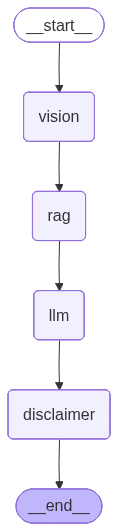

✅ Workflow visualization generated above


In [36]:
from IPython.display import Image, display

try:
    # Generate workflow visualization
    # This creates a visual graph of your agent pipeline
    workflow_image = app.get_graph().draw_mermaid_png()

    # Display the graph
    display(Image(workflow_image))
    print("✅ Workflow visualization generated above")

except Exception as e:
    print(f"⚠️ Visualization not available: {e}")
    print("You can still run the workflow without visualization!")
    print("\nWorkflow flow:")
    print("  START")
    print("    ↓")
    print("  VISION (detect pneumonia)")
    print("    ↓")
    print("  RAG (retrieve medical knowledge)")
    print("    ↓")
    print("  LLM (generate explanation)")
    print("    ↓")
    print("  DISCLAIMER (add safety warnings)")
    print("    ↓")
    print("  END")

In [37]:
import time

def run_langgraph_pipeline(image_path: str, roi_path: str) -> Dict[str, Any]:
    """
    Execute the complete LangGraph-based pipeline.

    Args:
        image_path: Path to original X-ray image
        roi_path: Path to ROI crop image

    Returns:
        Final state with all outputs
    """

    print("="*80)
    print("🤖 LANGGRAPH MULTI-AGENT PIPELINE")
    print("="*80)

    # Initialize state
    initial_state = {
        "image_path": image_path,
        "roi_image_path": roi_path,
        "vision_output": None,
        "detections": None,
        "predicted_class": None,
        "confidence": None,
        "rag_context": None,
        "medical_knowledge": None,
        "rag_source": None,
        "llm_explanation": None,
        "llm_model": None,
        "final_output": None,
        "risk_level": None,
        "step_latencies": {},
        "total_start_time": time.time(),
        "errors": [],
        "status": "in_progress"
    }

    # Start logging if available
    inference_data = None
    if logger:
        inference_data = logger.start_inference()

    # Execute the workflow
    try:
        final_state = app.invoke(initial_state)

        # Calculate total time
        total_time = time.time() - final_state["total_start_time"]

        # Log if available
        if logger and inference_data:
            for step_name, latency in final_state["step_latencies"].items():
                logger.log_step(inference_data, step_name, {}, latency)

            logger.complete_inference(
                inference_data=inference_data,
                final_output=final_state["final_output"],
                success=(final_state["status"] == "success"),
                error=", ".join(final_state["errors"]) if final_state["errors"] else None
            )

        # Print summary
        print("\n" + "="*80)
        print("✅ LANGGRAPH PIPELINE COMPLETE")
        print("="*80)
        print(f"Status: {final_state['status'].upper()}")
        print(f"Total time: {total_time:.3f}s")
        print(f"\nStep breakdown:")
        for step, latency in final_state["step_latencies"].items():
            percentage = (latency / total_time) * 100
            print(f"  {step.capitalize():12} {latency:.3f}s ({percentage:.1f}%)")

        if final_state["errors"]:
            print(f"\n⚠️ Errors encountered: {len(final_state['errors'])}")
            for error in final_state["errors"]:
                print(f"  - {error}")

        print("="*80)

        return final_state

    except Exception as e:
        print(f"\n❌ Pipeline execution failed: {str(e)}")

        if logger and inference_data:
            logger.complete_inference(
                inference_data=inference_data,
                final_output={},
                success=False,
                error=str(e)
            )

        raise


# Execute the pipeline
final_state = run_langgraph_pipeline(
    image_path="/content/drive/MyDrive/AI School Projects/Pneumonia LLM/IM-0501-0001-0002.jpeg",  # Replace with your actual path
    roi_path=roi_images[0] if roi_images else "/path/to/roi.jpg"
)

print("\n" + "="*80)
print("📊 FINAL STATE")
print("="*80)
print(f"Predicted Class: {final_state['predicted_class']}")
print(f"Confidence: {final_state['confidence']:.1f}%")
print(f"Risk Level: {final_state['risk_level']}")
print(f"RAG Source: {final_state['rag_source']}")
print(f"LLM Model: {final_state['llm_model']}")

🤖 LANGGRAPH MULTI-AGENT PIPELINE

🔍 VisionNode: Starting detection...
   Image path: /content/drive/MyDrive/AI School Projects/Pneumonia LLM/IM-0501-0001-0002.jpeg
   Calling Roboflow API...
   Processing results...
   ✅ Complete (2.530s)
   Assessment: No radiographic evidence of pneumonia detected
   Confidence: 98.8%
   Detections: 2

📚 RAGNode: Retrieving medical knowledge...
   ✅ Complete (0.000s)
   Source: Center Surgent Care - Pneumonia X-Ray Guide

🧠 LLMNode: Generating explanation with LLaVA...
   Calling LLaVA model (this may take 5-10 seconds)...
   Model response length: 600 chars
   ✅ Complete (13.883s)
   Generated: there are no radiographic signs of pneumonia detected. The absence of focal or lobar opacities, ill-defined, fluffy borders, dense, white areas in the...

⚠️  DisclaimerNode: Adding medical disclaimers...
   ✅ Complete (0.000s)
   Risk Level: STANDARD

✅ LANGGRAPH PIPELINE COMPLETE
Status: SUCCESS
Total time: 16.422s

Step breakdown:
  Vision       2.530s (15

In [38]:
# Display the formatted medical report
if final_state["final_output"]:
    formatted_report = disclaimer_agent.get_formatted_output(final_state["final_output"])
    print("\n" + formatted_report)
else:
    print("❌ No final output generated")

# Show session summary
if logger:
    logger.print_summary()



PNEUMONIA DETECTION SYSTEM - ANALYSIS REPORT

DETECTION RESULTS:
  • Class: NORMAL
  • Confidence: 98.85%
  • Risk Level: STANDARD

MEDICAL EXPLANATION:
there are no radiographic signs of pneumonia detected. The absence of focal or lobar opacities, ill-defined, fluffy borders, dense, white areas in the lungs, air-filled bronchi, hazy increased lung density, or loss of normal borders suggests that the lungs appear to be normal. The computer vision model's detection of two regions with an average confidence of 98.8% further supports this conclusion. While the presence of consolidation, air bronchograms, ground-glass opacities, silhouette sign, or pleural effusion would indicate pneumonia, these features are not observed in this particular X-ray.


⚠️ MEDICAL DISCLAIMER ⚠️
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

This analysis is for RESEARCH AND EDUCATIONAL PURPOSES ONLY.

IMPORTANT LIMITATIONS:
- This is an AI-assisted tool and should NOT be used 

In [39]:
# Install Gradio and image processing libraries
!pip install -q gradio pillow reportlab

print("✅ Gradio installed")
print("✅ PIL (image processing) ready")
print("✅ ReportLab (PDF generation) ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 35.6 MB/s eta 0:00:00
✅ Gradio installed
✅ PIL (image processing) ready
✅ ReportLab (PDF generation) ready


In [40]:
import gradio as gr
from PIL import Image, ImageDraw, ImageFont
import io
import time
from datetime import datetime
import json
from typing import Tuple, Optional
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
from reportlab.lib import colors
from reportlab.lib.enums import TA_CENTER, TA_LEFT

# Styling constants
COLORS = {
    'normal': '#28a745',      # Green
    'pneumonia': '#dc3545',   # Red
    'warning': '#ffc107',     # Yellow
    'info': '#17a2b8'         # Blue
}

print("✅ All libraries imported")
print("✅ Styling constants defined")

✅ All libraries imported
✅ Styling constants defined


In [41]:
def draw_bounding_boxes(image_path: str, detections: list) -> Image.Image:
    """
    Draw bounding boxes on the image for detected regions.

    Args:
        image_path: Path to the original image
        detections: List of detection dictionaries with bbox info

    Returns:
        PIL Image with bounding boxes drawn
    """
    # Load image
    img = Image.open(image_path).convert('RGB')
    draw = ImageDraw.Draw(img)

    # Try to use a nice font, fallback to default
    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 20)
    except:
        font = ImageFont.load_default()

    # Draw each detection
    for i, detection in enumerate(detections):
        bbox = detection.get('bbox', {})
        label = detection.get('label', 'unknown')
        confidence = detection.get('confidence', 0)

        # Extract bbox coordinates
        x = bbox.get('x', 0)
        y = bbox.get('y', 0)
        width = bbox.get('width', 0)
        height = bbox.get('height', 0)

        # Calculate corners
        left = x - width / 2
        top = y - height / 2
        right = x + width / 2
        bottom = y + height / 2

        # Choose color based on label
        if 'negative' in label.lower() or 'normal' in label.lower():
            color = COLORS['normal']
        else:
            color = COLORS['pneumonia']

        # Draw rectangle
        draw.rectangle(
            [(left, top), (right, bottom)],
            outline=color,
            width=4
        )

        # Draw label background
        label_text = f"{label} ({confidence*100:.1f}%)"
        text_bbox = draw.textbbox((left, top - 25), label_text, font=font)
        draw.rectangle(
            [(text_bbox[0] - 5, text_bbox[1] - 5), (text_bbox[2] + 5, text_bbox[3] + 5)],
            fill=color
        )

        # Draw label text
        draw.text((left, top - 25), label_text, fill='white', font=font)

    return img


def resize_for_display(image: Image.Image, max_width: int = 800) -> Image.Image:
    """
    Resize image for display while maintaining aspect ratio.

    Args:
        image: PIL Image
        max_width: Maximum width in pixels

    Returns:
        Resized PIL Image
    """
    if image.width > max_width:
        ratio = max_width / image.width
        new_height = int(image.height * ratio)
        image = image.resize((max_width, new_height), Image.Resampling.LANCZOS)

    return image


print("✅ Image processing functions defined")
print("   - draw_bounding_boxes(): Annotate detections")
print("   - resize_for_display(): Optimize for web display")

✅ Image processing functions defined
   - draw_bounding_boxes(): Annotate detections
   - resize_for_display(): Optimize for web display


In [42]:
def create_pdf_report(final_output: dict, image_path: str) -> str:
    """
    Generate a professional PDF report of the analysis.

    Args:
        final_output: Final output from disclaimer agent
        image_path: Path to the analyzed image

    Returns:
        Path to generated PDF file
    """
    # Create PDF filename
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    pdf_filename = f"/content/pneumonia_report_{timestamp}.pdf"

    # Create PDF document
    doc = SimpleDocTemplate(pdf_filename, pagesize=letter)
    story = []
    styles = getSampleStyleSheet()

    # Custom styles
    title_style = ParagraphStyle(
        'CustomTitle',
        parent=styles['Heading1'],
        fontSize=24,
        textColor=colors.HexColor('#2c3e50'),
        spaceAfter=30,
        alignment=TA_CENTER
    )

    heading_style = ParagraphStyle(
        'CustomHeading',
        parent=styles['Heading2'],
        fontSize=14,
        textColor=colors.HexColor('#34495e'),
        spaceAfter=12,
        spaceBefore=12
    )

    # Title
    story.append(Paragraph("PNEUMONIA DETECTION REPORT", title_style))
    story.append(Spacer(1, 0.3*inch))

    # Metadata
    story.append(Paragraph(f"Generated: {final_output.get('generated_at', 'N/A')}", styles['Normal']))
    story.append(Paragraph(f"Model: {final_output['metadata']['model_used']}", styles['Normal']))
    story.append(Spacer(1, 0.2*inch))

    # Detection Results
    story.append(Paragraph("DETECTION RESULTS", heading_style))

    results_data = [
        ['Metric', 'Value'],
        ['Predicted Class', final_output['predicted_class'].upper()],
        ['Confidence', f"{final_output['confidence']:.2f}%"],
        ['Risk Level', final_output['risk_level']]
    ]

    results_table = Table(results_data, colWidths=[2.5*inch, 3*inch])
    results_table.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
        ('ALIGN', (0, 0), (-1, -1), 'LEFT'),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('FONTSIZE', (0, 0), (-1, 0), 12),
        ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
        ('BACKGROUND', (0, 1), (-1, -1), colors.beige),
        ('GRID', (0, 0), (-1, -1), 1, colors.black)
    ]))

    story.append(results_table)
    story.append(Spacer(1, 0.3*inch))

    # Medical Explanation
    story.append(Paragraph("MEDICAL EXPLANATION", heading_style))
    story.append(Paragraph(final_output['medical_explanation'], styles['Normal']))
    story.append(Spacer(1, 0.3*inch))

    # Disclaimer
    story.append(Paragraph("MEDICAL DISCLAIMER", heading_style))
    disclaimer_text = final_output['disclaimer'].replace('\n', '<br/>')
    story.append(Paragraph(disclaimer_text, styles['Normal']))

    # Build PDF
    doc.build(story)

    print(f"✅ PDF report generated: {pdf_filename}")
    return pdf_filename


print("✅ PDF report generation function defined")

✅ PDF report generation function defined


In [43]:
def analyze_xray(image) -> Tuple[Image.Image, str, str, str, str]:
    """
    Main function that runs the complete analysis pipeline.
    This is what Gradio will call when user clicks "Analyze".

    Args:
        image: PIL Image or numpy array from Gradio

    Returns:
        Tuple of (annotated_image, results_html, explanation, disclaimer, pdf_path)
    """
    if image is None:
        return None, "❌ Please upload an image first", "", "", None

    try:
        # Save uploaded image temporarily
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        temp_image_path = f"/content/temp_xray_{timestamp}.jpg"

        # Convert to PIL if needed
        if not isinstance(image, Image.Image):
            image = Image.fromarray(image)

        image.save(temp_image_path)

        print(f"📥 Image saved: {temp_image_path}")

        # Initialize state for LangGraph
        initial_state = {
            "image_path": temp_image_path,
            "roi_image_path": temp_image_path,  # Using same image for ROI
            "vision_output": None,
            "detections": None,
            "predicted_class": None,
            "confidence": None,
            "rag_context": None,
            "medical_knowledge": None,
            "rag_source": None,
            "llm_explanation": None,
            "llm_model": None,
            "final_output": None,
            "risk_level": None,
            "step_latencies": {},
            "total_start_time": time.time(),
            "errors": [],
            "status": "in_progress"
        }

        print("🚀 Running LangGraph pipeline...")

        # Run the LangGraph workflow
        final_state = app.invoke(initial_state)

        # Calculate total time
        total_time = time.time() - final_state["total_start_time"]

        print(f"✅ Pipeline complete in {total_time:.2f}s")

        # Draw bounding boxes on image
        if final_state["detections"]:
            annotated_image = draw_bounding_boxes(temp_image_path, final_state["detections"])
            annotated_image = resize_for_display(annotated_image)
        else:
            annotated_image = resize_for_display(image)

        # Format results as HTML
        predicted_class = final_state["predicted_class"]
        confidence = final_state["confidence"]
        risk_level = final_state["risk_level"]

        # Determine color based on class
        if "normal" in predicted_class.lower() or "negative" in predicted_class.lower():
            color = COLORS['normal']
            emoji = "✅"
        else:
            color = COLORS['pneumonia']
            emoji = "🚨"

        results_html = f"""
        <div style="padding: 20px; background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); border-radius: 10px; color: white; margin: 10px 0;">
            <h2 style="margin: 0 0 15px 0;">{emoji} Detection Results</h2>
            <div style="background: rgba(255,255,255,0.1); padding: 15px; border-radius: 8px; margin: 10px 0;">
                <p style="margin: 5px 0; font-size: 18px;"><strong>Predicted Class:</strong> <span style="color: {color}; background: white; padding: 5px 10px; border-radius: 5px;">{predicted_class.upper()}</span></p>
                <p style="margin: 5px 0; font-size: 18px;"><strong>Confidence:</strong> {confidence:.2f}%</p>
                <p style="margin: 5px 0; font-size: 18px;"><strong>Risk Level:</strong> {risk_level}</p>
                <p style="margin: 5px 0; font-size: 14px; opacity: 0.9;"><strong>Processing Time:</strong> {total_time:.2f}s</p>
            </div>
        </div>
        """

        # Get explanation
        explanation = final_state["llm_explanation"] or "No explanation generated"

        # Format explanation nicely
        explanation_html = f"""
        <div style="padding: 20px; background: #f8f9fa; border-left: 4px solid #007bff; border-radius: 5px; margin: 10px 0;">
            <h3 style="margin-top: 0; color: #007bff;">🧠 Medical Explanation</h3>
            <p style="line-height: 1.6; color: #333;">{explanation}</p>
            <hr style="border: none; border-top: 1px solid #dee2e6; margin: 15px 0;">
            <p style="font-size: 12px; color: #6c757d; margin: 0;">
                <strong>Source:</strong> {final_state.get('rag_source', 'Medical Knowledge Base')}
            </p>
        </div>
        """

        # Get disclaimer
        disclaimer_text = final_state["final_output"]["disclaimer"]

        # Format disclaimer
        disclaimer_html = f"""
        <div style="padding: 20px; background: #fff3cd; border: 2px solid #ffc107; border-radius: 5px; margin: 10px 0;">
            <h3 style="margin-top: 0; color: #856404;">⚠️ IMPORTANT MEDICAL DISCLAIMER</h3>
            <pre style="white-space: pre-wrap; font-family: inherit; color: #856404; margin: 0;">{disclaimer_text}</pre>
        </div>
        """

        # Generate PDF report
        pdf_path = create_pdf_report(final_state["final_output"], temp_image_path)

        return annotated_image, results_html, explanation_html, disclaimer_html, pdf_path

    except Exception as e:
        error_msg = f"❌ Error during analysis: {str(e)}"
        print(error_msg)
        import traceback
        traceback.print_exc()
        return None, error_msg, "", "", None


print("✅ Main analysis function defined")
print("   This function orchestrates the entire pipeline for Gradio")

✅ Main analysis function defined
   This function orchestrates the entire pipeline for Gradio


In [44]:
import os, glob
import gradio as gr

# ---- PATH TO YOUR EXAMPLE IMAGES ----
EXAMPLES_DIR = "/content/drive/MyDrive/AI School Projects/Pneumonia LLM"

def get_example_paths(folder, limit=12):
    exts = ("*.png", "*.jpg", "*.jpeg", "*.webp")
    paths = []
    for ext in exts:
        paths += glob.glob(os.path.join(folder, "**", ext), recursive=True)
    return sorted(paths)[:limit]

example_paths = get_example_paths(EXAMPLES_DIR, limit=12)

# Custom CSS for professional styling
custom_css = """
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700&display=swap');

#title {
    text-align: center;
    background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
    color: white;
    padding: 30px;
    border-radius: 10px;
    margin-bottom: 20px;
}

#subtitle {
    text-align: center;
    color: #666;
    font-size: 18px;
    margin-bottom: 22px;
}

.gradio-container {
    max-width: 1200px !important;
    margin: auto !important;
    font-family: Inter, ui-sans-serif, system-ui, -apple-system, "Segoe UI", Roboto, Arial, "Noto Sans", "Helvetica Neue", sans-serif;
}

.output-image {
    border: 2px solid #667eea;
    border-radius: 10px;
}

.examples-wrap {
    border: 1px solid rgba(0,0,0,0.08);
    border-radius: 12px;
    padding: 14px;
    background: white;
    margin-bottom: 18px;
}

.examples-hint {
    text-align: center;
    font-weight: 700;
    font-size: 16px;
    margin-bottom: 10px;
}

/* Hide upload affordances so user can't upload their own */
.no-upload [data-testid="upload-button"],
.no-upload input[type="file"],
.no-upload .wrap.svelte-1ipelgc,                 /* older gradio upload wrapper */
.no-upload .upload-box,
.no-upload .image-container .tool,
.no-upload .image-container button {
    display: none !important;
}
"""

with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:

    # Header
    gr.HTML("""
        <div id="title">
            <h1 style="margin: 0; font-size: 36px;">🏥 Pneumonia Detection System</h1>
            <p style="margin: 10px 0 0 0; font-size: 18px; opacity: 0.9;">AI-Powered Chest X-Ray Analysis</p>
        </div>
    """)

    gr.HTML("""
        <div id="subtitle">
            <p>Select a chest X-ray example for automated pneumonia detection using multi-agent AI system</p>
            <p style="font-size: 14px; color: #999;">Powered by: Roboflow Vision + Medical RAG + Qwen2-VL + LangGraph</p>
        </div>
    """)

    # ✅ Examples at the very top
    with gr.Group(elem_classes=["examples-wrap"]):
        gr.HTML('<div class="examples-hint"> Click any example X-ray to load it</div>')

        # This is still the "input" image your pipeline reads, but we hide upload UI via CSS
        input_image = gr.Image(
            label="Selected X-Ray",
            type="pil",
            height=420,
            elem_classes=["no-upload"],
            interactive=True,  # Needed for Examples to work
            show_download_button=False,
            show_share_button=False
        )

        if len(example_paths) == 0:
            gr.Markdown(
                f"**No images found** in:\n\n`{EXAMPLES_DIR}`\n\n"
                "✅ Make sure Drive is mounted and the folder contains .png/.jpg/.jpeg/.webp files."
            )
        else:
            gr.Examples(
                examples=[[p] for p in example_paths],
                inputs=input_image,
                label="Example Images (click to select)"
            )

    with gr.Row():
        with gr.Column(scale=1):
            analyze_btn = gr.Button("🔍 Analyze Selected X-Ray", variant="primary", size="lg")
            clear_btn = gr.ClearButton(components=[input_image], value="🗑️ Clear", size="lg")

        with gr.Column(scale=1):
            gr.Markdown("### 🖼️ Annotated Image")
            output_image = gr.Image(
                label="Detection Results",
                type="pil",
                height=420,
                elem_classes=["output-image"]
            )

    # Results section
    gr.Markdown("---")
    gr.Markdown("## 📊 Analysis Results")
    results_display = gr.HTML(label="Detection Results")
    explanation_display = gr.HTML(label="Medical Explanation")
    disclaimer_display = gr.HTML(label="Medical Disclaimer")

    # Download section
    gr.Markdown("---")
    gr.Markdown("### 📥 Download Report")
    pdf_output = gr.File(label="Download PDF Report")

    # Footer
    gr.HTML("""
        <div style="text-align: center; padding: 20px; color: #999; font-size: 12px; margin-top: 30px; border-top: 1px solid #eee;">
            <p><strong>⚠️ DISCLAIMER:</strong> This system is for research and educational purposes only.
            Not intended for clinical diagnosis. Always consult qualified healthcare professionals.</p>
            <p>Developed with ❤️ using LangGraph, Gradio, and open-source AI models</p>
        </div>
    """)

    analyze_btn.click(
        fn=analyze_xray,
        inputs=[input_image],
        outputs=[output_image, results_display, explanation_display, disclaimer_display, pdf_output]
    )

print("✅ Gradio interface created")
print(f"✅ Found {len(example_paths)} example images in: {EXAMPLES_DIR}")


✅ Gradio interface created
✅ Found 5 example images in: /content/drive/MyDrive/AI School Projects/Pneumonia LLM


---

# 🚀 Deployment & Sharing

## Gradio Share Feature

When we launch with `share=True`, Gradio creates:
- **Local URL**: For testing on your machine
- **Public URL**: Shareable link valid for 72 hours

### Public URL Features:
✅ Share with anyone (no account needed)
✅ Works on mobile devices
✅ Perfect for demos and interviews
✅ No deployment complexity
✅ Completely FREE

### Use Cases:
- **Portfolio**: Add to your resume/GitHub
- **Interviews**: Live demo during technical rounds
- **Collaboration**: Share with medical professionals for feedback
- **Presentations**: Show at conferences/meetups

## Deployment Options

| Platform | Cost | Persistence | Best For |
|----------|------|-------------|----------|
| **Gradio Share** | FREE | 72 hours | Demos, testing |
| **HuggingFace Spaces** | $0-432/mo | Permanent | Public deployment |
| **AWS/GCP** | $50-500/mo | Permanent | Enterprise |
| **Local Server** | FREE | While running | Development |

## Production Checklist

Before sharing publicly:
- [ ] Test with diverse X-ray images
- [ ] Verify all disclaimers are visible
- [ ] Check PDF report generation
- [ ] Monitor for errors in logs
- [ ] Ensure API keys are secure
- [ ] Review medical accuracy with experts

## Performance Metrics

Expected performance:
- **Vision Agent**: 1-2 seconds
- **RAG Retrieval**: 0.1-0.3 seconds
- **LLM Inference**: 3-5 seconds
- **PDF Generation**: 0.2-0.5 seconds
- **Total Pipeline**: 5-8 seconds

---

**Ready to launch!** Run the cell below to start the Gradio interface.

---

In [45]:
# Launch the interface
print("="*80)
print("🚀 LAUNCHING GRADIO INTERFACE")
print("="*80)

demo.launch(
    share=True,          # Create public shareable link (valid for 72 hours)
    debug=True,          # Show detailed error messages
    show_error=True,     # Display errors in UI
    server_name="0.0.0.0",  # Allow external connections
    server_port=7860     # Default Gradio port
)

print("\n✅ Gradio interface is live!")
print("\nYou now have:")
print("   1. Local URL (for testing)")
print("   2. Public URL (shareable link - valid 72 hours)")
print("\n📱 The public URL can be:")
print("   - Shared with anyone")
print("   - Added to your resume")
print("   - Tested on mobile devices")
print("   - Used in presentations")

🚀 LAUNCHING GRADIO INTERFACE
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://9d5fecc7db34e70d88.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


📥 Image saved: /content/temp_xray_20260201_050410.jpg
🚀 Running LangGraph pipeline...

🔍 VisionNode: Starting detection...
   Image path: /content/temp_xray_20260201_050410.jpg
   Calling Roboflow API...
   Processing results...
   ✅ Complete (0.317s)
   Assessment: Pneumonia detected
   Confidence: 68.7%
   Detections: 1

📚 RAGNode: Retrieving medical knowledge...
   ✅ Complete (0.000s)
   Source: Center Surgent Care - Pneumonia X-Ray Guide

🧠 LLMNode: Generating explanation with LLaVA...
   Calling LLaVA model (this may take 5-10 seconds)...
   Model response length: 663 chars
   ✅ Complete (11.785s)
   Generated: I observed multiple focal or lobar opacities in various locations within the lungs. These opacities have ill-defined, fluffy borders, which are indica...

⚠️  DisclaimerNode: Adding medical disclaimers...
   ✅ Complete (0.000s)
   Risk Level: HIGH
✅ Pipeline complete in 12.11s
✅ PDF report generated: /content/pneumonia_report_20260201_050422.pdf
📥 Image saved: /content/temp

# **FAILED API CALLS**

In [ ]:
!pip install groq

from groq import Groq
import base64

client = Groq(api_key="api_key")

with open(roi_images[0], "rb") as image_file:
    base64_image = base64.b64encode(image_file.read()).decode('utf-8')

completion = client.chat.completions.create(
    model="llama-3.2-90b-vision-preview",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": f"""Medical imaging analysis..."""
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/png;base64,{base64_image}"
                    }
                }
            ]
        }
    ],
    max_tokens=300
)

print(completion.choices[0].message.content)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.3/138.3 kB 6.4 MB/s eta 0:00:00


BadRequestError: Error code: 400 - {'error': {'message': 'The model `llama-3.2-90b-vision-preview` has been decommissioned and is no longer supported. Please refer to https://console.groq.com/docs/deprecations for a recommendation on which model to use instead.', 'type': 'invalid_request_error', 'code': 'model_decommissioned'}}

In [ ]:
import anthropic
import base64

client = anthropic.Anthropic(api_key="your-key-here")

# Read and encode image
with open(roi_images[0], "rb") as image_file:
    image_data = base64.standard_b64encode(image_file.read()).decode("utf-8")

message = client.messages.create(
    model="claude-sonnet-4-20250514",
    max_tokens=300,
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "source": {
                        "type": "base64",
                        "media_type": "image/png",
                        "data": image_data,
                    },
                },
                {
                    "type": "text",
                    "text": f"""You are a medical imaging assistant.
A computer vision model analyzed a chest X-ray and produced the following structured findings:
{json.dumps(structured_output, indent=2)}

Based ONLY on the findings and the provided image:
- Explain whether the case is consistent with pneumonia or normal lungs
- Use cautious medical language
- Do not introduce new findings
- State uncertainty if confidence < 0.7"""
                }
            ],
        }
    ],
)

print(message.content[0].text)